## colunas analisadas:   **Income + Age + Dependents + Occupation + City_Tier **

Importaçao das bibliotecas

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Abrindo o csv, e testando se carregou corretamente

In [5]:
df = pd.read_csv('../dataset/data.csv')
df.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


— Renda Média por Faixa Etária


Objetivo: investigar se a renda cresce de forma consistente com a idade. O raciocínio passa por dois momentos: primeiro, cria-se a variável Age_Group usando pd.cut(), que transforma a coluna contínua Age em cinco faixas discretas (18-25, 26-35, 36-45, 46-55, 55+). Em seguida, calcula-se a média de Income por grupo e plota-se um gráfico de barras. A visualização permite identificar em qual faixa a renda atinge o pico e se há queda após determinada idade — padrão típico de aposentadoria ou mudança de ocupação.

C:\Users\USER\AppData\Local\Temp\ipykernel_21104\557542656.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=renda_idade, x='Age_Group', y='Income', palette='Blues_d')


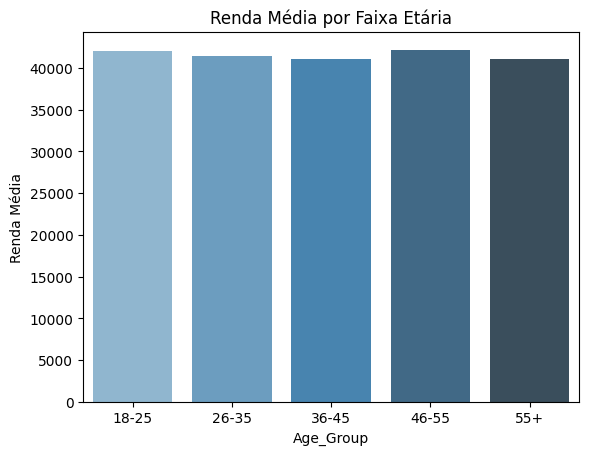

In [6]:
# Média de renda por faixa etária
df['Age_Group'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 70],
                          labels=['18-25', '26-35', '36-45', '46-55', '55+'])

renda_idade = df.groupby('Age_Group')['Income'].mean().reset_index()

sns.barplot(data=renda_idade, x='Age_Group', y='Income', palette='Blues_d')
plt.title('Renda Média por Faixa Etária')
plt.ylabel('Renda Média')
plt.show()

Distribuição e Instabilidade de Renda por Ocupação


Objetivo: ir além da média e entender a dispersão da renda dentro de cada ocupação. O boxplot revela simultaneamente a mediana, os quartis e os outliers — o que é muito mais informativo do que uma simples média, pois expõe se uma ocupação tem renda relativamente uniforme entre seus membros ou altamente concentrada. O coeficiente de variação (CV%) calculado na sequência formaliza isso numericamente: ocupações com CV alto indicam renda instável ou heterogênea, o que é um sinal de risco financeiro estrutural para aquele grupo.

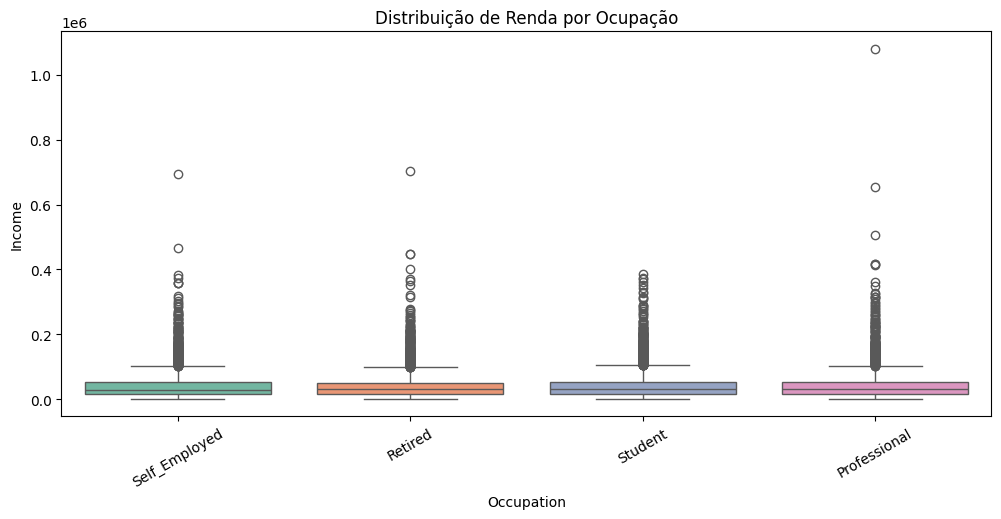

,Media,Desvio,CV (%)
Occupation,,,
Professional,42020.474941,42891.886289,102.07
Self_Employed,41829.155645,40064.600746,95.78
Retired,40666.767123,37969.709858,93.37
Student,41829.582625,38961.923791,93.14


In [7]:
# Boxplot revela mediana E dispersão (instabilidade)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Occupation', y='Income', palette='Set2', hue='Occupation', legend=False)
plt.title('Distribuição de Renda por Ocupação')
plt.xticks(rotation=30)
plt.show()

# Coeficiente de variação por ocupação (quanto maior, mais instável)
cv = df.groupby('Occupation')['Income'].agg(
    Media='mean', Desvio='std'
)
cv['CV (%)'] = (cv['Desvio'] / cv['Media'] * 100).round(2)
display(cv.sort_values('CV (%)', ascending=False))

Comprometimento da Renda com Gastos Fixos por City Tier


Objetivo: medir a pressão orçamentária imposta pelo contexto urbano antes mesmo de qualquer gasto variável. O raciocínio cria primeiro uma variável Fixed_Expenses somando Rent, Loan_Repayment e Insurance — os três componentes inelásticos do orçamento — e depois calcula Fixed_Ratio como proporção da renda total. Ao agrupar por City_Tier, o gráfico responde a uma questão central: cidades de tier mais alto consomem proporcionalmente mais renda com custos fixos, mesmo quando a renda nominal é maior? A resposta a essa pergunta revela se o custo de vida urbano cancela o ganho de renda das grandes cidades.

C:\Users\USER\AppData\Local\Temp\ipykernel_21104\3172045395.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pressao, x='City_Tier', y='Fixed_Ratio', palette='Reds_d')


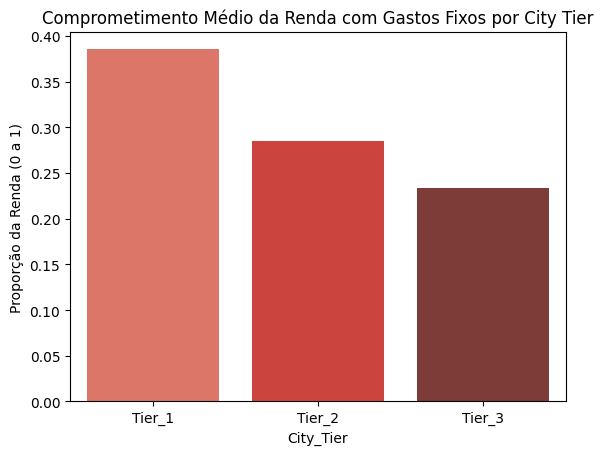

In [8]:
# Calculando razão entre gastos fixos e renda
df['Fixed_Expenses'] = df['Rent'] + df['Loan_Repayment'] + df['Insurance']
df['Fixed_Ratio'] = df['Fixed_Expenses'] / df['Income']

pressao = df.groupby('City_Tier')['Fixed_Ratio'].mean().reset_index()

sns.barplot(data=pressao, x='City_Tier', y='Fixed_Ratio', palette='Reds_d')
plt.title('Comprometimento Médio da Renda com Gastos Fixos por City Tier')
plt.ylabel('Proporção da Renda (0 a 1)')
plt.show()

Mapa de Correlação Geral


Objetivo: ter uma visão panorâmica das relações entre todas as variáveis numéricas do dataset de uma só vez. O heatmap de correlação com cmap='coolwarm' e center=0 destaca visualmente as correlações positivas fortes (azul intenso), negativas fortes (vermelho intenso) e ausência de relação (branco). O annot=False foi escolhido para manter o gráfico legível dado o número elevado de colunas — anotar os valores tornaria o mapa ilegível. Essa célula funciona como bússola exploratória, apontando quais pares de variáveis merecem investigação mais aprofundada nas células seguintes.

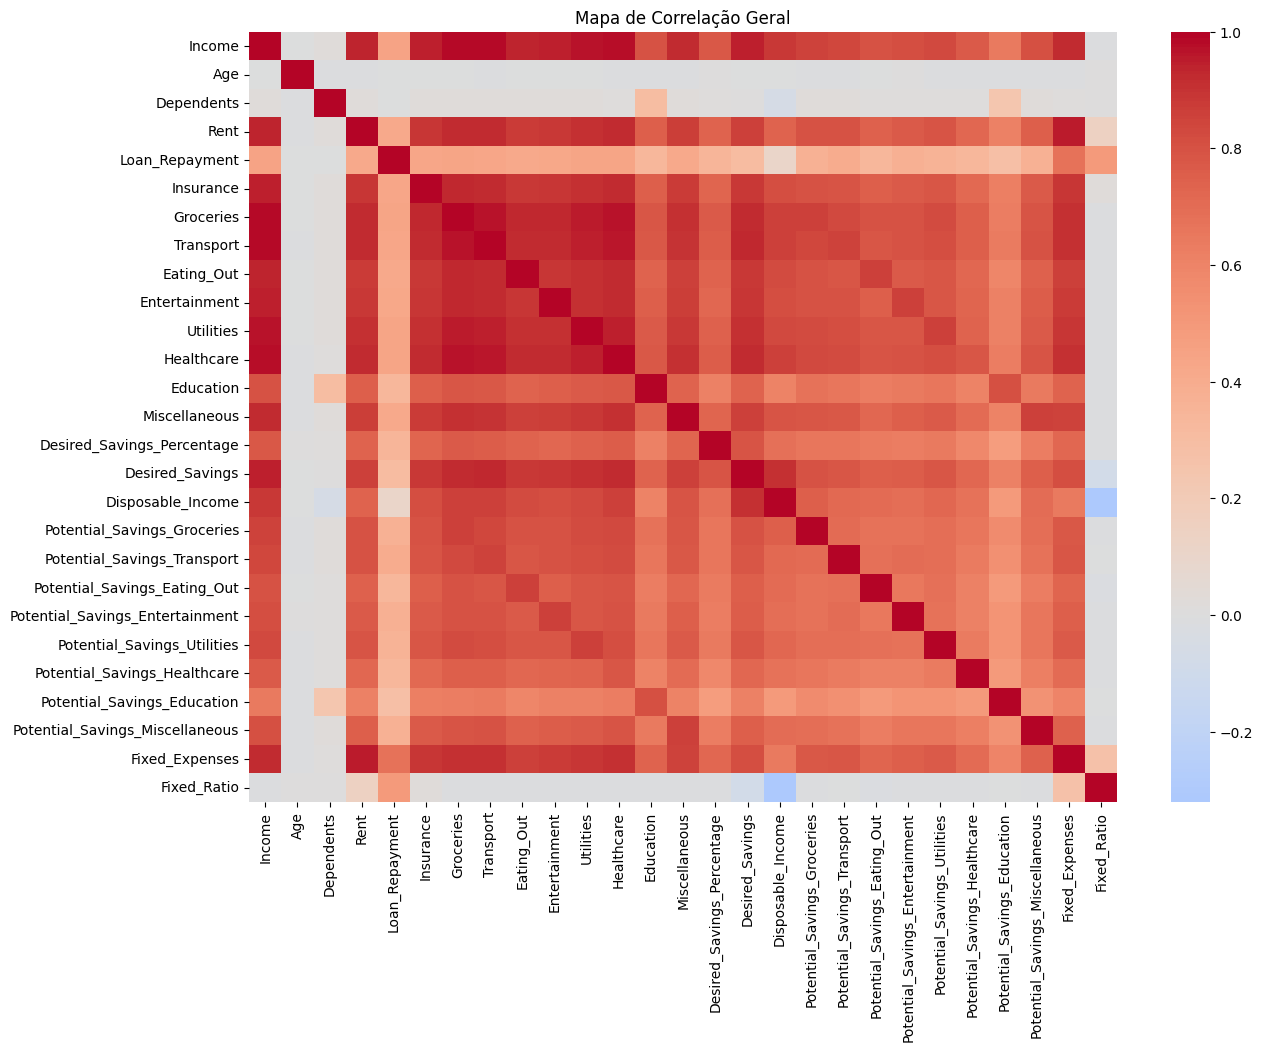

In [9]:
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Mapa de Correlação Geral')
plt.show()

Perfil Agregado por Ocupação e City Tier


Objetivo: construir uma tabela de perfil cruzado que resume, para cada combinação de ocupação e cidade, cinco métricas simultaneamente: renda média, idade média, número médio de dependentes, comprometimento com gastos fixos e percentual de poupança desejada. O raciocínio é de síntese — em vez de analisar cada variável separadamente, essa célula permite comparar perfis completos lado a lado. É especialmente útil para identificar combinações que parecem contraditórias, como alta renda com alto comprometimento fixo, ou baixa renda com alta aspiração de poupança

In [10]:
perfil = df.groupby(['Occupation', 'City_Tier']).agg(
    Renda_Media=('Income', 'mean'),
    Idade_Media=('Age', 'mean'),
    Dependentes_Medio=('Dependents', 'mean'),
    Comprometimento_Fixo=('Fixed_Ratio', 'mean'),
    Poupanca_Desejada=('Desired_Savings_Percentage', 'mean')
).round(2).reset_index()

print(perfil)

       Occupation City_Tier  Renda_Media  Idade_Media  Dependentes_Medio  \
0    Professional    Tier_1     41607.67        41.32               1.99   
1    Professional    Tier_2     41693.04        41.08               2.01   
2    Professional    Tier_3     43421.17        41.11               1.96   
3         Retired    Tier_1     39567.68        41.64               2.04   
4         Retired    Tier_2     41015.79        40.92               1.96   
5         Retired    Tier_3     41443.02        41.55               1.98   
6   Self_Employed    Tier_1     40478.91        40.60               1.98   
7   Self_Employed    Tier_2     42842.89        40.87               1.99   
8   Self_Employed    Tier_3     41256.51        41.04               2.04   
9         Student    Tier_1     42652.50        40.52               2.04   
10        Student    Tier_2     41304.66        41.12               1.98   
11        Student    Tier_3     41956.83        40.78               2.00   

    Comprom

Ciclo de Vida Financeiro (Heatmap)


Objetivo: entender como o número de dependentes afeta a renda disponível ao longo das diferentes fases da vida. O agrupamento duplo por Age_Group e Dependents gera uma visão matricial que é então convertida em heatmap via pivot. A cor mais intensa indica maior renda disponível — e o padrão esperado é que a célula mais crítica (cor mais fria) apareça na faixa dos 36-45 anos com dois ou mais dependentes, quando os gastos com educação e saúde já cresceram mas a renda ainda não atingiu o pico. Essa célula mapeia exatamente onde o ciclo de vida cria o maior stress financeiro.

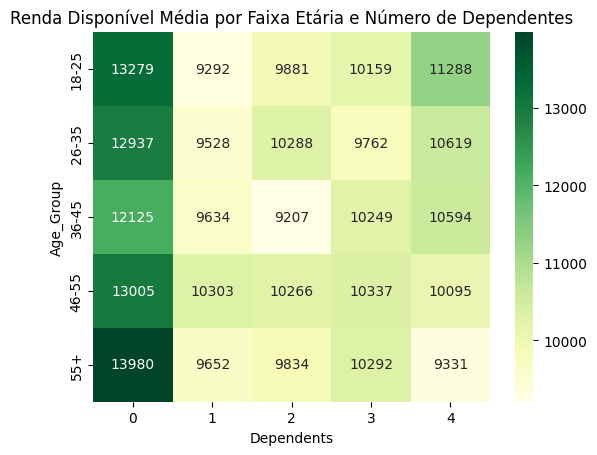

In [11]:
# A ideia aqui é ver como os dependentes modulam o impacto da renda ao longo da vida
ciclo = df.groupby(['Age_Group', 'Dependents']).agg(
    Renda_Media=('Income', 'mean'),
    Disposable_Media=('Disposable_Income', 'mean'),
    Poupanca_Real=('Desired_Savings', 'mean')
).round(2).reset_index()

# Heatmap: Age_Group x Dependents -> Disposable_Income médio
pivot = ciclo.pivot(index='Age_Group', columns='Dependents', values='Disposable_Media')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGn')
plt.title('Renda Disponível Média por Faixa Etária e Número de Dependentes')
plt.show()

Trajetória de Renda por Ocupação ao Longo da Vida


Objetivo: verificar se diferentes ocupações produzem trajetórias de renda distintas à medida que as pessoas envelhecem. Usando a mediana (mais robusta que a média contra outliers), o gráfico de linhas com marcadores mostra para cada ocupação como a renda evolui faixa a faixa. O raciocínio é preditivo: ocupações com crescimento linear contínuo indicam progressão de carreira sólida, enquanto aquelas com platô precoce ou queda revelam tetos de renda que comprometem a capacidade de poupança no longo prazo. Esse gráfico é essencialmente uma curva de ciclo de vida financeiro segmentada por tipo de trabalho.

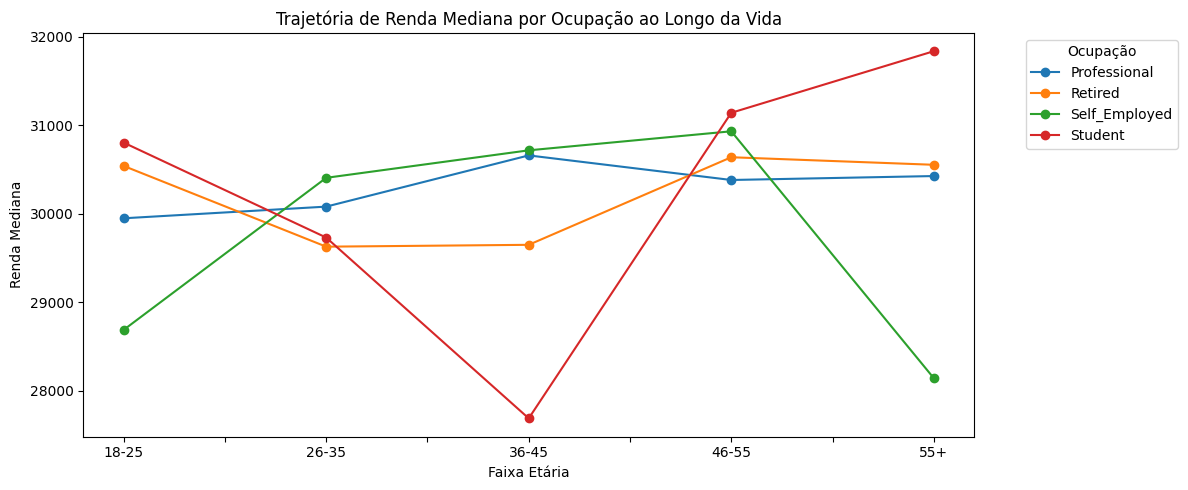

In [12]:
# Vê se a ocupação prediz a trajetória de renda ao longo da vida
traj = df.groupby(['Occupation', 'Age_Group'])['Income'].median().unstack()

traj.T.plot(figsize=(12, 5), marker='o')
plt.title('Trajetória de Renda Mediana por Ocupação ao Longo da Vida')
plt.ylabel('Renda Mediana')
plt.xlabel('Faixa Etária')
plt.legend(title='Ocupação', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()